In [1]:
# чтение данных из базы

import pandas as pd
from sklearn.metrics import mean_squared_error
import joblib
import json
import yaml
import os
from sklearn.model_selection import train_test_split
import os, psycopg
from dotenv import load_dotenv
load_dotenv()

TABLE_NAME = "users_churn"# таблица с данными

connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:

    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df[:2]

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,2043,7361-YPXFS,2017-10-01,NaT,Month-to-month,No,Bank transfer (automatic),64.45,1867.6,DSL,...,Yes,Yes,No,No,Female,1,No,No,Yes,0
1,2044,6557-BZXLQ,2018-10-01,NaT,Month-to-month,No,Electronic check,69.65,1043.3,Fiber optic,...,No,No,No,No,Male,1,No,No,No,0


In [2]:
# трансформация (AutoFeat)
from autofeat import AutoFeatClassifier


# разделяем признаки на категории и числа
cat_columns = [
    'type',
    'paperless_billing',
    'payment_method',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'multiple_lines'
]
num_columns = [
    'monthly_charges',
    'total_charges'
]

# прибираемся в данных
df[num_columns] = df[num_columns].fillna(df[num_columns].mean())
df[cat_columns] = df[cat_columns].fillna(df[cat_columns].mode().iloc[0])
df = df[cat_columns+num_columns+['target']]

# разделяем данные на выборки
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['target']), df['target'], test_size=0.2, random_state=42
)

# определяем трансформации для генерации признаков
transformations = ('1/', 'log', 'abs', 'sqrt')

# обучение
afc = AutoFeatClassifier(
    categorical_cols=cat_columns,
    transformations=transformations,
    feateng_steps=1, 
    n_jobs=-1
)
X_train_features = afc.fit_transform(X_train, y_train)

X_test_features = afc.transform(X_test)

X_train_features.head(2)
X_test_features.head(2)


/home/mle-user/mle-projects/mle-mlflow/.venv_notebook/lib/python3.10/site-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


,monthly_charges,total_charges,cat_type_Month-to-month,cat_type_One year,cat_type_Two year,cat_paperless_billing_No,cat_paperless_billing_Yes,cat_payment_method_Bank transfer (automatic),cat_payment_method_Credit card (automatic),cat_payment_method_Electronic check,...,cat_gender_Male,cat_senior_citizen_0,cat_senior_citizen_1,cat_partner_No,cat_partner_Yes,cat_dependents_No,cat_dependents_Yes,cat_multiple_lines_No,cat_multiple_lines_Yes,log(total_charges)
0,100.2,6851.65,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,8.832245
1,104.6,6819.45,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,8.827534


In [11]:
# Отбор признаков 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from catboost import CatBoostClassifier

estimator = RandomForestClassifier(n_estimators=300)

sfs = SFS(
    estimator,
    k_features=10,
    forward=True,
    floating=False,
    scoring='roc_auc',
    cv=4,
    n_jobs=-1, verbose=2
)
sfs = sfs.fit(X_train_features, y_train)

top_sfs = sfs.k_feature_names_

print('\nSequential Forward Selection (k=10)')
print('CV Score:')
print(sfs.k_score_)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  1.4min finished

[2025-09-14 09:33:59] Features: 1/10 -- score: 0.7268726798062395[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:  1.3min finished

[2025-09-14 09:35:17] Features: 2/10 -- score: 0.7722734734421723[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  34 | elapsed:  1.3min finished

[2025-09-14 09:36:34] Features: 3/10 -- score: 0.7874128275296892[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  33 | elapsed:  1.3min finished

[2025-09-14 09:37:51] Features: 4/10 -- score: 0.7939432519568613[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 out of  32 | elapsed:  1.3min finished




Sequential Forward Selection (k=10)
CV Score:
0.8020044753782809

Sequential Backward Selection
CV Score:


[Parallel(n_jobs=-1)]: Done  27 out of  27 | elapsed:  1.2min finished

[2025-09-14 09:45:23] Features: 10/10 -- score: 0.8020044753782809

In [13]:
# Отбор признаков 2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from catboost import CatBoostClassifier

estimator = RandomForestClassifier(n_estimators=300)

sbs = SFS(
    estimator,
    k_features=10,
    forward=False,
    floating=False,
    scoring='roc_auc',
    cv=4,
    n_jobs=-1,  verbose=2
)
sbs = sbs.fit(X_train_features, y_train)

top_sbs = sbs.k_feature_names_

print('\nSequential Backward Selection')
print('CV Score:')
print(sbs.k_score_)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  3.2min finished

[2025-09-14 09:53:00] Features: 35/10 -- score: 0.8233546835005738[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:  3.1min finished

[2025-09-14 09:56:05] Features: 34/10 -- score: 0.8238669998214935[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 out of  34 | elapsed:  3.0min finished

[2025-09-14 09:59:04] Features: 33/10 -- score: 0.8251259281867303[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  33 | elapsed:  2.9min finished

[2025-09-14 10:02:00] Features: 32/10 -- score: 0.8254094670365371[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 out of  32 | elapsed:  2.8min finish


Sequential Backward Selection
CV Score:
0.8187322494527778


[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:  1.1min finished

[2025-09-14 10:44:09] Features: 10/10 -- score: 0.8187322494527778

In [17]:
# Сохранение результата
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T 

FS_ASSETS = 'assets'
#os.mkdir(FS_ASSETS, exist_ok=True)

sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv") 
sfs_df.head(2)
sbs_df.head(2)

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
36,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.8171677720335317, 0.8459896840747905, 0.809...",0.823038,"(monthly_charges, total_charges, cat_type_Mont...",0.022134,0.013808,0.007972
35,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.8177264628946882, 0.847217279174726, 0.8086...",0.823355,"(monthly_charges, total_charges, cat_type_Mont...",0.023081,0.014399,0.008313


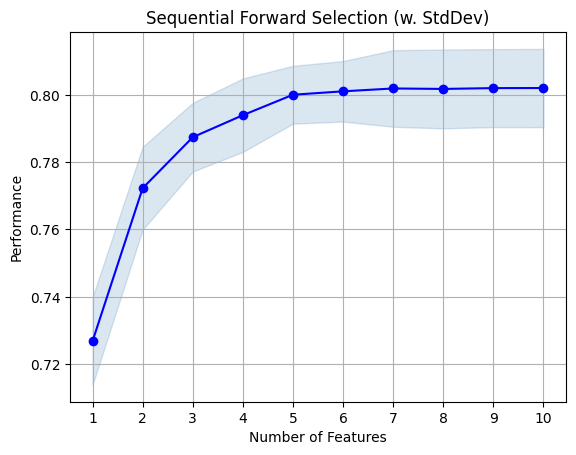

<Figure size 640x480 with 0 Axes>

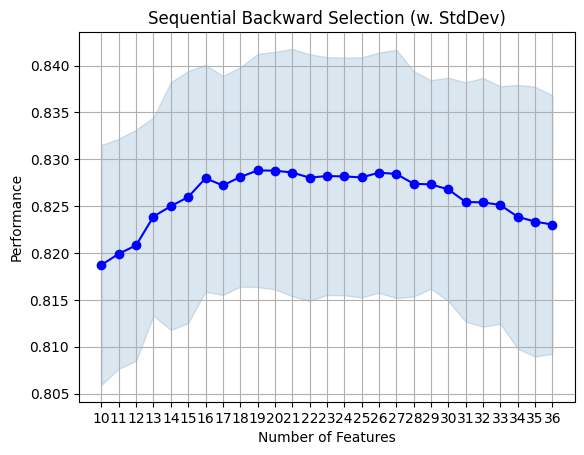

<Figure size 640x480 with 0 Axes>

In [18]:
# отрисовка графиков
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sfs.png") 

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sbs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sbs.png") 

In [19]:
# объединение признаком
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))
interc_features
union_features

['cat_internet_service_Fiber optic',
 'monthly_charges',
 'cat_tech_support_No',
 'cat_type_Two year',
 'cat_paperless_billing_No',
 'cat_senior_citizen_1',
 'cat_online_backup_Yes',
 'log(total_charges)',
 'cat_tech_support_Yes',
 'cat_payment_method_Electronic check',
 'cat_internet_service_DSL',
 'cat_streaming_movies_Yes',
 'cat_paperless_billing_Yes',
 'cat_type_Month-to-month',
 'cat_partner_No',
 'cat_gender_Male',
 'total_charges']

In [20]:
# Сохраняем артефакты

import os
import mlflow
import mlflow.sklearn
import pandas as pd

EXPERIMENT_NAME = "churn"
RUN_NAME = "sfs_sbs_data"
#REGISTRY_MODEL_NAME = "churn_model_arvas"


os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = "YCAJE3Nlz8iDILW5VTYM1ihQB"
os.environ["AWS_SECRET_ACCESS_KEY"] = "YCPjvS7uwhvJpUj3bKm8X-IX4QAwBIVsvX61IL44"

mlflow.set_tracking_uri("http://localhost:5000")

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_intersection_and_union", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
   
    mlflow.log_artifacts(FS_ASSETS) 

2025-09-14 10:49:47,473 INFO: Found credentials in environment variables.


In [21]:
run_id

'2cc523155ac14e369d4bfbc14c7e0c45'

In [26]:
# обучение модели на feature_selection_intersection

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from category_encoders import CatBoostEncoder
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

model = CatBoostClassifier(auto_class_weights='Balanced', verbose=0)

model.fit(X_train_features[interc_features], y_train) 

print (model)

In [27]:
# Предсказания и оценка
prediction = model.predict(X_test_features[interc_features])
prediction_proba = model.predict_proba(X_test_features[interc_features])[:, 1]
print(prediction)
print(prediction_proba)

# Вычисление метрик
from sklearn.metrics import f1_score, roc_auc_score
f1 = f1_score(y_test, prediction)
roc_auc = roc_auc_score(y_test, prediction_proba)
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")


[1 0 0 ... 0 0 1]
[0.7857274  0.0941456  0.17697979 ... 0.17697979 0.0941456  0.7857274 ]
F1 Score: 0.5883554647599591
ROC AUC: 0.8050173850394688


In [29]:
# Сохранение модели и метрик

import os
import mlflow
import mlflow.sklearn
import pandas as pd

EXPERIMENT_NAME = "feature_selection_intersection"
RUN_NAME = "feature_selection_intersection"
REGISTRY_MODEL_NAME = "churn_model_arvas"


os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = "YCAJE3Nlz8iDILW5VTYM1ihQB"
os.environ["AWS_SECRET_ACCESS_KEY"] = "YCPjvS7uwhvJpUj3bKm8X-IX4QAwBIVsvX61IL44"

mlflow.set_tracking_uri("http://localhost:5000")

pip_requirements = 'requirements.txt'
signature = mlflow.models.infer_signature(X_test_features, prediction)
input_example = X_test_features[:10]
metadata = {'model_learn': 'feature_selection_intersection'}

print (model)
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    # ваш код здесь
    model_info = mlflow.catboost.log_model(
        cb_model=model,  # Ваш обученный экземпляр модели DecisionTreeClassifier
        artifact_path='models',
        registered_model_name=REGISTRY_MODEL_NAME,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        pip_requirements=pip_requirements,
        await_registration_for=60
    )
    # Логирование метрик
    mlflow.log_metric("F1_Score", f1)
    mlflow.log_metric("ROC_AUC", roc_auc)

Registered model 'churn_model_arvas' already exists. Creating a new version of this model...
2025/09/14 10:57:48 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: churn_model_arvas, version 7
Created version '7' of model 'churn_model_arvas'.


In [30]:
# обучение модели на feature_selection_union

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from category_encoders import CatBoostEncoder
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

model = CatBoostClassifier(auto_class_weights='Balanced', verbose=0)

model.fit(X_train_features[union_features], y_train) 

print (model)

In [31]:
# Предсказания и оценка
prediction = model.predict(X_test_features[union_features])
prediction_proba = model.predict_proba(X_test_features[union_features])[:, 1]
print(prediction)
print(prediction_proba)

# Вычисление метрик
from sklearn.metrics import f1_score, roc_auc_score
f1 = f1_score(y_test, prediction)
roc_auc = roc_auc_score(y_test, prediction_proba)
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")

[1 0 0 ... 0 0 1]
[0.56773994 0.26797978 0.02075286 ... 0.03510909 0.01565683 0.67441374]
F1 Score: 0.6346368715083799
ROC AUC: 0.8476459716827466


In [32]:
# Сохранение модели и метрик

import os
import mlflow
import mlflow.sklearn
import pandas as pd

EXPERIMENT_NAME = "feature_selection_union"
RUN_NAME = "feature_selection_union"
REGISTRY_MODEL_NAME = "churn_model_arvas"


os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
os.environ["AWS_ACCESS_KEY_ID"] = "YCAJE3Nlz8iDILW5VTYM1ihQB"
os.environ["AWS_SECRET_ACCESS_KEY"] = "YCPjvS7uwhvJpUj3bKm8X-IX4QAwBIVsvX61IL44"

mlflow.set_tracking_uri("http://localhost:5000")

pip_requirements = 'requirements.txt'
signature = mlflow.models.infer_signature(X_test_features, prediction)
input_example = X_test_features[:10]
metadata = {'model_learn': 'feature_selection_union'}

print (model)
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    # ваш код здесь
    model_info = mlflow.catboost.log_model(
        cb_model=model,  # Ваш обученный экземпляр модели DecisionTreeClassifier
        artifact_path='models',
        registered_model_name=REGISTRY_MODEL_NAME,
        signature=signature,
        input_example=input_example,
        metadata=metadata,
        pip_requirements=pip_requirements,
        await_registration_for=60
    )
    # Логирование метрик
    mlflow.log_metric("F1_Score", f1)
    mlflow.log_metric("ROC_AUC", roc_auc)

Registered model 'churn_model_arvas' already exists. Creating a new version of this model...
2025/09/14 10:58:18 INFO mlflow.tracking._model_registry.client: Waiting up to 60 seconds for model version to finish creation. Model name: churn_model_arvas, version 8
Created version '8' of model 'churn_model_arvas'.
